#### Simple Exponential Smoothing(SES)

1.  SES stands  for Simple Exponential Smoothing. It is a time series forecasting technique that is used when

    (a.)    there is no trend in the data

    (b.)    there is no seasonality in the data

    (c.)     We want to predict the future values based on the weighted average of the past observations.

2.  Here the recent observations get more weights and the older observations get less weights.

#### Problem Statement

1.  The amin aim of the problem statement is to

    (a.)    apply Simple Exponential Smoothing on the time series dataset and forecast the sales for the next six months.

#### Step 1:    Import all  the necessary libraries

In [1014]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    statsmodels.tsa.holtwinters import  SimpleExpSmoothing

#### OBSERVATIONS:

1.  SimpleExpSmoothing =========> 

    (a.)    It is used when no trend and seasonality is there. 
    
    (b.)    The future values are forecasted based on the weighted average of past observations where the recent observations are given more weights than the past observations.

#### Step 2: Create a Sample Time Series Dataset

In [1015]:
data = {
    'Month': [
        '2025-01','2025-02','2025-03','2025-04',
        '2025-05','2025-06','2025-07','2025-08',
        '2025-09','2025-10','2025-11','2025-12'
    ],
    
    'Sales': [
        120, 135, 128, 140,
        150, 145, 160, 170,
        165, 180, 175, 190
    ]
}

In [1016]:
data

{'Month': ['2025-01',
  '2025-02',
  '2025-03',
  '2025-04',
  '2025-05',
  '2025-06',
  '2025-07',
  '2025-08',
  '2025-09',
  '2025-10',
  '2025-11',
  '2025-12'],
 'Sales': [120, 135, 128, 140, 150, 145, 160, 170, 165, 180, 175, 190]}

In [1017]:
#### Convert the data into the dataframe

df = pd.DataFrame(data)

In [1018]:
df

,Month,Sales
0,2025-01,120
1,2025-02,135
2,2025-03,128
3,2025-04,140
4,2025-05,150
5,2025-06,145
6,2025-07,160
7,2025-08,170
8,2025-09,165
9,2025-10,180


#### OBSERVATIONS:

1.  The above dataset represents the monthly wise sales data for the year 2025.

#### Step 3: Perform the Data Exploration

In [1019]:
#### get the first five rows of the dataset

df.head()

,Month,Sales
0,2025-01,120
1,2025-02,135
2,2025-03,128
3,2025-04,140
4,2025-05,150


In [1020]:
#### get the last five rows of the dataset

df.tail()

,Month,Sales
7,2025-08,170
8,2025-09,165
9,2025-10,180
10,2025-11,175
11,2025-12,190


In [1021]:
#### get the length of the dataset

print("Length of the dataset is:", len(df))

Length of the dataset is: 12


In [1022]:
#### get the shape of the dataset

print("Shape of the dataset is:", df.shape)

Shape of the dataset is: (12, 2)


In [1023]:
#### get the columns used in the dataset

df.columns

Index(['Month', 'Sales'], dtype='object')

In [1024]:
#### get the information about the columns used in the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Month   12 non-null     object
 1   Sales   12 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 320.0+ bytes


#### OBSERVATIONS:

1.  The Month column is object in type.

In [1025]:
#### get the descriptive summary statistics about the numerical columns used in the dataset

df.describe()

,Sales
count,12.000000
mean,154.833333
std,21.957949
min,120.000000
25%,138.750000
50%,155.000000
75%,171.250000
max,190.000000


In [1026]:
#### get the descriptive summary statistics about the categorical columns used in the dataset

df.describe(include='object')

,Month
count,12
unique,12
top,2025-01
freq,1


#### OBSERVATIONS:

1.  The above dataset explains the descriptive statictical summary for each column used in the dataset.

#### Step 4: Perform Data Cleaning and Feature Engineering

In [1027]:
#### convert the object type of date column to datetime

df['Month'] =   pd.to_datetime(df['Month'])

In [1028]:
#### get the information about the columns used in the revised dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Month   12 non-null     datetime64[ns]
 1   Sales   12 non-null     int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 320.0 bytes


#### OBSERVATIONS:

1.  The onject type in the Month column has been converted to datetime.

In [1029]:
#### To check for the NULL records in the dataset

df.isnull().sum()

Month    0
Sales    0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [1030]:
#### To check for the duplicate records used in the dataset

df[df.duplicated()]

,Month,Sales


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

In [1031]:
#### Set the Month column as an index

df.set_index('Month',inplace=True)

In [1032]:
df.head()

,Sales
Month,
2025-01-01,120
2025-02-01,135
2025-03-01,128
2025-04-01,140
2025-05-01,150


#### OBSERVATIONS:

1.  The month column has been set as an index in the dataframe.

#### Step 5: Plot the Original Time series data

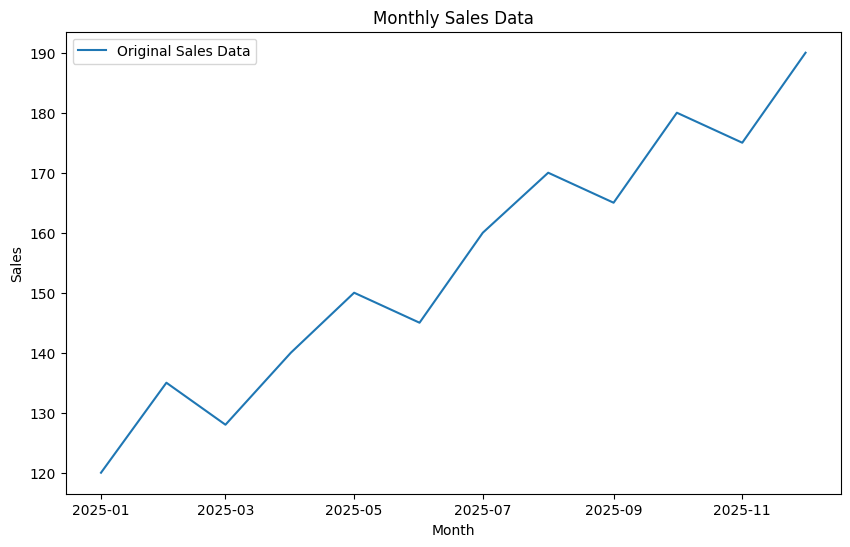

In [1033]:
plt.figure(figsize=(10,6))

#### perform the plotting of the original time series data
plt.plot(df.index, df['Sales'], label = 'Original Sales Data')

#### give the title of the graph
plt.title('Monthly Sales Data')

#### give the xaxis of the graph
plt.xlabel('Month')

#### give the yaxis of the graph
plt.ylabel('Sales')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph represents the sales data of the customer per month for the year 2025.

2.  As the month increases and passes by, the sales data increases exponentially and the graph shows an upward trend.

#### Step 6: Import the library for Simple Exponential Smoothing

In [1034]:
from  statsmodels.tsa.holtwinters import SimpleExpSmoothing

#### Step 7: Apply the Simple Exponential Smoothing on the sales column of the dataset

In [1035]:
#### Apply the SES model

model=SimpleExpSmoothing(df['Sales'])

c:\Users\DELL\Desktop\Complete_Data_Science\vens\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [1036]:
model

#### OBSERVATIONS:

1.  Here the Simple Exponential Smoothing is applied on the sales column of the dataframe and we get the model for SES.

#### Step 8: Train the Simple Exponential Smoothing model

In [1037]:
#### Train the model

model_fit=model.fit(
    smoothing_level =   0.3         ,
    optimized       =   False
)

#### OBSERVATIONS:

1.  The SES model has been trained with the help of the following parameters :-------------

    (a.)    smoothing_level ===========>  It controls the importance of the recent observations.

            If the smoothing_level is very low, then it is less rective to the recent changes.

            If the smoothing_level is very high, then it is highly reactive to the recent changes.

            The smoothing level must lie between 0 to 1.


    (b.)    optimized = False ==============> It will not automatically calculate the best alpha weights.

#### Step 9: Get the fitted/predicted values

In [1038]:
#### To get the fitted values
df['SES_fitted'] = model_fit.fittedvalues

In [1039]:
df

,Sales,SES_fitted
Month,,
2025-01-01,120,120.000000
2025-02-01,135,120.000000
2025-03-01,128,124.500000
2025-04-01,140,125.550000
2025-05-01,150,129.885000
2025-06-01,145,135.919500
2025-07-01,160,138.643650
2025-08-01,170,145.050555
2025-09-01,165,152.535388


#### OBSERVATIONS:

1.  Here we have obtained all the fitted / predicted sales values and is stored inside the new column named 'SES_fitted'.

#### Step 10: Plot the Original vs Fitted Values

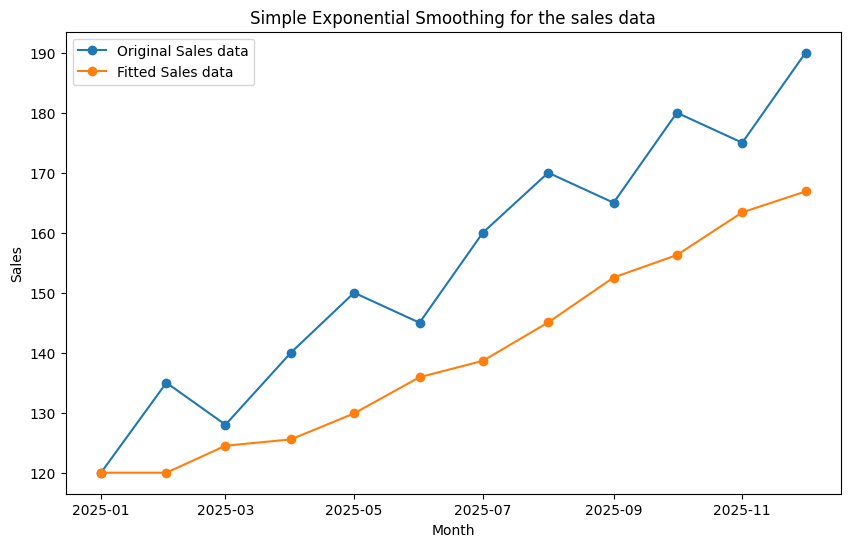

In [1040]:
plt.figure(figsize=(10,6))

#### plot the original sales data
plt.plot(df.index, df['Sales'], marker='o',label='Original Sales data')

#### plot the fitted sales data
plt.plot(df.index, df['SES_fitted'], marker='o', label='Fitted Sales data')

#### get the title of the graph
plt.title('Simple Exponential Smoothing for the sales data')

#### get the x axis of the graph
plt.xlabel('Month')

#### get the y axis of the graph
plt.ylabel('Sales')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The original sales data shows the trend and seasonality in the graph.

2.  But the SES fitted sales data does not have any repeated seasonal patterns but it shows a partial upward trend. This is because:-----

    (a.)    The recent observations have higher values than the initial observations of the sales fitted data.

    (b.)    So more weights will be given to the recent observations than the initial observations.

    (c.)    So based on the recent observations, the SES will update the values and will follow an upward movement.

#### Step 11: Perform the forecasting of the future values

In [1041]:
#### perform the forecasting of the dataset

forecasting_values = model_fit.forecast(steps=len(df))

In [1042]:
forecasting_values

2026-01-01    173.812247
2026-02-01    173.812247
2026-03-01    173.812247
2026-04-01    173.812247
2026-05-01    173.812247
2026-06-01    173.812247
2026-07-01    173.812247
2026-08-01    173.812247
2026-09-01    173.812247
2026-10-01    173.812247
2026-11-01    173.812247
2026-12-01    173.812247
Freq: MS, dtype: float64

#### OBSERVATIONS:

1.  It performs the forecasting of the sales value for the next 12 months.

#### Step 12: Perform the plotting of the forecasted future values

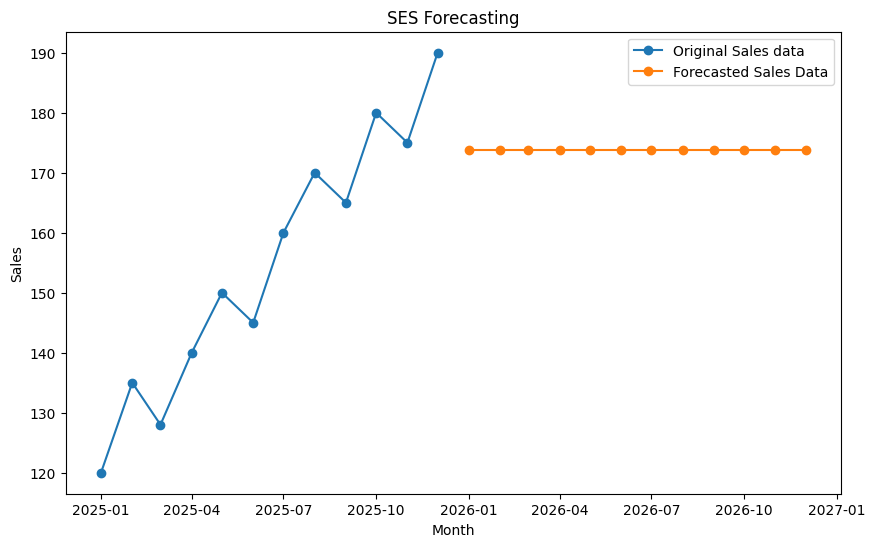

In [1043]:
plt.figure(figsize=(10,6))

#### perform the plotting of the original sales data
plt.plot(df.index, df['Sales'], marker='o', label = 'Original Sales data')

#### perform the plotting of the forecasted sales data
plt.plot(forecasting_values.index, forecasting_values.values, marker='o', label = 'Forecasted Sales Data')

#### give the title of the graph
plt.title('SES Forecasting')

#### give the x axis of the graph
plt.xlabel('Month')

#### give the y axis of the graph
plt.ylabel('Sales')

plt.legend()

#### display the graph
plt.show()

#### OBSERVATIONS:

1.  The above graph shows that the original data shows trends and seasonality with repeating patterns for the year 2025.

2.  But the future 12 months data year 2026, the data is completely constant and there is no trend or sesonality.

#### CONCLUSIONS:

1.  We see an upward trend in the fitted values . This is because :------------

    (a.)    The fitted values comes from the actual values of the dataset.

    (b.)    The SES model is initially trained and it has access to all the actual values.

    (c.)    So the model has to update itself with the changes in the actual values.

    (d.)    The fitted values also keeps increasing with respect to the actual values.

    (e.)    So the SES model has to adjust with respect to the actual values. So it shows an upward trend.


2.  But forecasted data shows no trend. This is because:------------------

    (a.)    The forecasted value has only future dates and no actual data.

    (b.)    So it coniders the values as the last actual value of the dataset for the next forecasted period.

    (c.)    This is the reason that the forecasted line is constant and showing no ternd in the data.